## Гига М.Я. М80-313Б-33

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
import sklearn.metrics as metrics
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import scipy.stats as stats

import lightgbm
import xgboost
import catboost
import optuna

from typing import Any, Tuple, cast

pd.options.display.max_columns = None

import warnings

warnings.filterwarnings("ignore")

utility functions

In [152]:
def z_score_scaler(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    return (data - mean) / (std)


def cont_to_binary(data: np.ndarray) -> np.ndarray:
    return (data >= 0.5).astype(int)

In [153]:
df_with_na = pd.read_csv("./data/train_c.csv")
df_with_na.describe()

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
count,10487.000000,10487.000000,9986.000000,9986.000000,10487.000000,10487.000000,9986.000000,10487.000000,10487.000000,10487.000000,10487.000000,9986.000000,10487.000000,10487.000000,10487.000000,10487.000000,9986.000000,9.986000e+03,1.048700e+04,10487.000000,10487.000000,10487.000000,10487.000000,9.986000e+03,9986.000000,10487.000000,10487.000000,10487.000000,10487.000000
mean,39.850386,131587.872127,678.082716,29874.218306,53.439878,1.568323,546.458642,0.284397,3.033565,0.979498,0.250610,0.052574,0.096405,24.008868,15.625250,5484.590159,1988.494893,1.830476e+05,6.881696e+04,10838.934141,0.784428,4.949271,17.628302,1.542381e+05,0.200392,0.200112,1075.622426,0.517577,0.511776
std,11.614132,115791.941909,175.192486,27705.509722,24.493562,1.418684,501.981888,0.159240,1.740186,0.990927,0.144543,0.223192,0.295160,4.844917,8.680774,8490.327012,3047.919512,4.673964e+05,2.032359e+05,9385.924858,0.123039,2.201100,11.337248,4.622229e+05,0.094388,0.096458,1344.053181,0.894637,0.499885
min,18.000000,15000.000000,300.000000,1063.000000,12.000000,0.000000,13.000000,0.003674,0.000000,0.000000,0.003227,0.000000,0.000000,8.000000,1.000000,31.000000,16.000000,8.920000e+02,7.800000e+01,1250.000000,0.259301,0.000000,0.000000,1.004000e+03,0.052494,0.046445,30.008506,0.006064,0.000000
25%,32.000000,20959.500000,550.000000,12658.000000,36.000000,0.000000,233.250000,0.158929,2.000000,0.000000,0.138695,0.000000,0.000000,21.000000,8.000000,1397.000000,533.250000,2.311100e+04,7.983500e+03,1683.541667,0.708475,3.000000,9.000000,7.252500e+03,0.119908,0.119548,375.872620,0.066734,0.000000
50%,40.000000,89015.000000,722.500000,21828.500000,48.000000,1.000000,398.000000,0.262229,3.000000,1.000000,0.228638,0.000000,0.000000,24.000000,16.000000,2961.000000,1122.500000,6.054350e+04,2.262500e+04,7371.250000,0.803692,5.000000,17.000000,2.742950e+04,0.182023,0.180710,684.878529,0.178193,1.000000
75%,48.000000,257025.000000,850.000000,37158.000000,60.000000,3.000000,685.000000,0.391683,4.000000,2.000000,0.341013,0.000000,0.000000,27.000000,23.000000,6222.500000,2300.000000,1.616955e+05,5.951700e+04,21232.583333,0.879312,6.000000,26.000000,1.241758e+05,0.264709,0.264880,1279.930203,0.637457,1.000000
max,80.000000,748508.000000,850.000000,418997.000000,120.000000,6.000000,10879.000000,0.914635,12.000000,6.000000,0.865842,1.000000,1.000000,44.000000,30.000000,222556.000000,109245.000000,1.128946e+07,8.997054e+06,25000.000000,0.996573,17.000000,57.000000,1.126117e+07,0.722497,0.833647,29634.807816,24.383046,1.000000


In [154]:
null_info = df_with_na.isna().apply(lambda x: x.sum())
null_info  # pyright: ignore[reportUnusedExpression]

ApplicationDate                530
Age                            530
AnnualIncome                   530
CreditScore                   1031
LoanAmount                    1031
LoanDuration                   530
MaritalStatus                  530
NumberOfDependents             530
HomeOwnershipStatus            530
MonthlyDebtPayments           1031
CreditCardUtilizationRate      530
NumberOfOpenCreditLines        530
NumberOfCreditInquiries        530
DebtToIncomeRatio              530
BankruptcyHistory             1031
LoanPurpose                   1031
PreviousLoanDefaults           530
PaymentHistory                 530
LengthOfCreditHistory          530
SavingsAccountBalance          530
CheckingAccountBalance        1031
TotalAssets                   1031
TotalLiabilities               530
MonthlyIncome                  530
UtilityBillsPaymentHistory     530
JobTenure                      530
EmploymentStatus               530
EducationLevel                 530
Experience          

In [155]:
df_filled = df_with_na.dropna()
X_raw = df_filled.drop(columns=["LoanApproved"])
y_raw = cast(pd.Series, df_filled["LoanApproved"])

<Axes: >

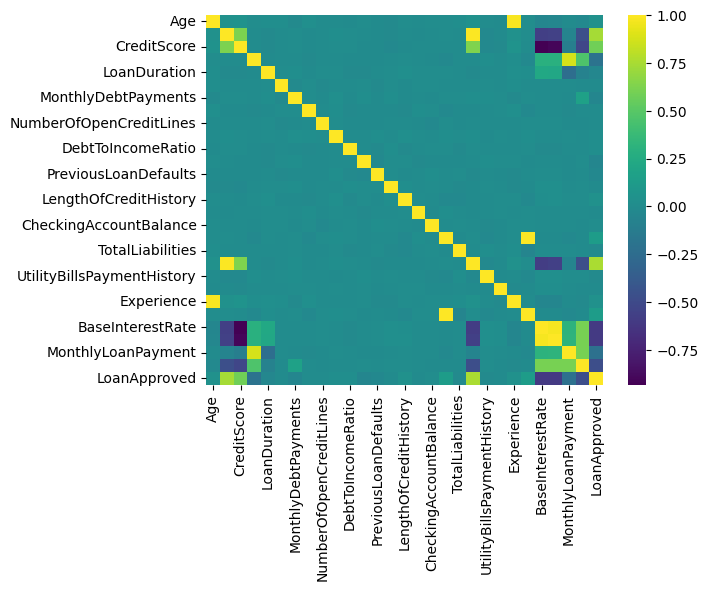

In [156]:
sns.heatmap(df_filled.select_dtypes(include=np.number).corr(),
            annot=False,
            cmap="viridis")

In [157]:
if False:
    for col in df_filled.select_dtypes(include=np.number).columns:
        sns.histplot(x=df_filled[col])
        plt.title(col)
        plt.show()

In [158]:
class MyBaggingClassifier:

    def __init__(self,
                 estimator: Any = DecisionTreeClassifier(),
                 n_estimators: int = 10,
                 sample_size: int = 1,
                 random_state: int | None = None):
        self.est = estimator
        self.n_estimators = n_estimators
        self.sample_size = sample_size
        self.random_state = random_state

    def _prepare(self, X: np.ndarray,
                 y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        n_samples = X.shape[0]
        size = n_samples * self.sample_size
        indices = np.random.choice(n_samples, size=size, replace=True)
        return X[indices], y[indices]

    def _conv(self, val: Any):
        if isinstance(val, pd.DataFrame) or isinstance(val, pd.Series):
            val = val.to_numpy()
        return val

    def fit(self, X: np.ndarray | Any, y: np.ndarray | Any):
        if self.random_state is not None:
            np.random.seed(self.random_state)

        X, y = self._conv(X), self._conv(y)
        self.estimators = []
        for _ in range(self.n_estimators):
            X_bs, y_bs = self._prepare(X, y)

            model: Any = clone(self.est)
            model.fit(X_bs, y_bs)
            self.estimators.append(model)

        return self

    def predict(self, X: np.ndarray | Any) -> np.ndarray:
        X = self._conv(X)
        preds = np.column_stack([est.predict(X) for est in self.estimators])
        preds, _ = stats.mode(
            preds,
            axis=1,
        )
        return preds.ravel()

    def predict_proba(self, X: np.ndarray | Any) -> np.ndarray:
        X = self._conv(X)
        preds = np.column_stack(
            [est.predict_proba(X) for est in self.estimators])
        return preds.mean(axis=1)

In [159]:
col_cat = X_raw.select_dtypes(include=["object"]).columns
col_cat = []
col_num = X_raw.select_dtypes(include=[np.number]).columns
col_all = np.concat([col_cat, col_num])

numerical_transformer = Pipeline(steps=[("scaler", StandardScaler())])

categorical_transformer = Pipeline(
    steps=[("onehot",
            OneHotEncoder(
                handle_unknown="ignore", sparse_output=False, drop="first"))])

pipe = Pipeline(steps=[
    ("preprocessor",
     ColumnTransformer(transformers=[
         ("num", numerical_transformer, col_num),
         ("cat", categorical_transformer, col_cat),
     ])),
])

col_all  # pyright: ignore[reportUnusedExpression]

array(['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration',
       'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio',
       'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure',
       'Experience', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio'], dtype=object)

In [160]:
X_train, X_test, y_train, y_test = train_test_split(X_raw[col_all],
                                                    y_raw,
                                                    random_state=42,
                                                    test_size=0.33)
X_train = pipe.fit_transform(X_train, y_train)
X_test = pipe.transform(X_test)
X_train.shape

(6690, 28)

In [161]:
%%time
bag_sk = BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=0)
bag_sk.fit(X_train, y_train)
bag_sk_pred = bag_sk.predict(X_test)
roc_auc_score(y_test, bag_sk_pred)

CPU times: user 515 ms, sys: 5.39 ms, total: 521 ms
Wall time: 521 ms


0.9204648438363431

In [162]:
%%time
bag_my = MyBaggingClassifier(estimator=DecisionTreeClassifier(),
                             random_state=0)
bag_my.fit(X_train, y_train)
bag_my_pred = bag_my.predict(X_test)
roc_auc_score(y_test, cont_to_binary(bag_my_pred))

CPU times: user 745 ms, sys: 3.54 ms, total: 749 ms
Wall time: 748 ms


0.9180223690899848

In [163]:
def accuracy_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return np.sum(y_true == y_pred) / len(y_true)


def precision_score(y_true: np.ndarray,
                    y_pred: np.ndarray,
                    average: str = "binary",
                    pos_label=1) -> float | np.float32:
    if average == "binary":
        tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
        fp = np.sum((y_true != pos_label) & (y_pred == pos_label))
        return 0 if tp + fp == 0 else tp / (tp + fp)

    labels = np.unique(np.concatenate([y_true, y_pred]))
    precisions = []
    for label in labels:
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        precision = 0 if tp + fp == 0 else tp / (tp + fp)
        precisions.append(precision)
    if average == "macro":
        return np.mean(precisions)
    elif average == "weighted":
        support = np.array([np.sum(y_true == label) for label in labels])
        return np.average(precisions, weights=support)
    elif average == "micro":
        tp_t = 0
        fp_t = 0
        for label in labels:
            tp_t += np.sum((y_true == label) & (y_pred == label))
            fp_t += np.sum((y_true != label) & (y_pred == label))
        return 0 if tp_t + fp_t == 0 else tp_t / (tp_t + fp_t)
    else:
        raise RuntimeError(f"invalid average: '{average}'")


def recall_score(y_true: np.ndarray,
                 y_pred: np.ndarray,
                 average="binary",
                 pos_label=1) -> float | np.float32:

    if average == "binary":
        tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
        fn = np.sum((y_true == pos_label) & (y_pred != pos_label))
        return 0 if tp + fn == 0 else tp / (tp + fn)

    labels = np.unique(np.concatenate([y_true, y_pred]))
    recalls = []
    for label in labels:
        tp = np.sum((y_true == label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))
        recall = 0 if tp + fn == 0 else tp / (tp + fn)
        recalls.append(recall)
    if average == "macro":
        return np.mean(recalls)
    elif average == "weighted":
        support = np.array([np.sum(y_true == label) for label in labels])
        return np.average(recalls, weights=support)
    elif average == "micro":
        tp_t = 0
        fn_t = 0
        for label in labels:
            tp_t += np.sum((y_true == label) & (y_pred == label))
            fn_t += np.sum((y_true == label) & (y_pred != label))
        return 0 if tp_t + fn_t == 0 else tp_t / (tp_t + fn_t)
    else:
        raise RuntimeError(f"invalid average: '{average}'")


def f1_score(y_true: np.ndarray,
             y_pred: np.ndarray,
             average="binary",
             pos_label=1) -> float | np.float32:
    if average == "binary" or average == "micro":
        p = precision_score(y_true,
                            y_pred,
                            average=average,
                            pos_label=pos_label)
        r = recall_score(y_true, y_pred, average=average, pos_label=pos_label)
        return 0 if p + r == 0 else 2 * (p * r) / (p + r)
    else:
        labels = np.unique(np.concatenate([y_true, y_pred]))
        f1_scores = []
        for label in labels:
            f1_scores.append(
                f1_score(y_true, y_pred, average="binary", pos_label=label))
        if average == "macro":
            return np.mean(f1_scores)
        elif average == "weighted":
            support = np.array([np.sum(y_true == label) for label in labels])
            return np.average(f1_scores, weights=support)
        else:
            raise RuntimeError(f"invalid average: '{average}'")

In [164]:
pred_bin = cont_to_binary(bag_my_pred)
scores = pd.DataFrame()
scores["type"] = [
    "accuracy_score", "precision_score", "recall_score", "f1_score"
]
scores["sklearn"] = [
    metrics.accuracy_score(y_test, pred_bin),
    metrics.precision_score(y_test, pred_bin),
    metrics.recall_score(y_test, pred_bin),
    metrics.f1_score(y_test, pred_bin)
]
y_test = cast(np.ndarray, y_test)
scores["my"] = [
    accuracy_score(y_test, pred_bin),
    precision_score(y_test, pred_bin),
    recall_score(y_test, pred_bin),
    f1_score(y_test, pred_bin)
]
scores  # pyright: ignore[reportUnusedExpression]

,type,sklearn,my
0,accuracy_score,0.917779,0.917779
1,precision_score,0.930091,0.930091
2,recall_score,0.907473,0.907473
3,f1_score,0.918643,0.918643


In [165]:
class MyGradientBoostingClassifier:

    def __init__(self,
                 learning_rate: float = 0.1,
                 n_estimators: int = 100,
                 max_depth: int = 3,
                 min_samples_leaf: int = 1,
                 min_samples_split: int = 2,
                 random_state: float | None = None) -> None:
        self.learning_rate = learning_rate
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.min_samples_split = min_samples_split
        self.random_state = random_state

    def _conv(self, val: Any) -> np.ndarray:
        if isinstance(val, pd.DataFrame) or isinstance(val, pd.Series):
            val = val.to_numpy()
        return val

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X: np.ndarray | Any, y: np.ndarray | Any):
        if self.random_state is not None:
            np.random.seed(self.random_state)

        X, y = self._conv(X), self._conv(y)

        pos_prob = np.mean(y)

        self.initial_prediction = np.log(pos_prob / (1 - pos_prob))
        self.trees = []

        current_predictions = np.full(len(y), self.initial_prediction)

        for _ in range(self.n_estimators):
            current_probs = self._sigmoid(current_predictions)
            residuals = y - current_probs

            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                random_state=self.random_state)
            tree.fit(X, residuals)

            tree_predictions = tree.predict(X)
            current_predictions += self.learning_rate * tree_predictions
            self.trees.append(tree)
        return self

    def predict(self, X: np.ndarray | Any) -> np.ndarray:
        probs = self.predict_proba(X)[:, 1]
        return (probs >= 0.5).astype(int)

    def predict_proba(self, X: np.ndarray | Any) -> np.ndarray:
        X = self._conv(X)
        predictions = np.full(len(X), self.initial_prediction)

        for tree in self.trees:
            predictions += self.learning_rate * tree.predict(X)
        prob_positive = self._sigmoid(predictions)
        return np.column_stack([1 - prob_positive, prob_positive])

In [166]:
%%time
grad_sk = GradientBoostingClassifier(random_state=0)
grad_sk.fit(X_train, y_train)
grad_sk_pred = grad_sk.predict(X_test)
roc_auc_score(y_test, grad_sk_pred)

CPU times: user 3.03 s, sys: 18.7 ms, total: 3.05 s
Wall time: 3.12 s


0.9343611620727513

In [167]:
%%time
grad_my = MyGradientBoostingClassifier(random_state=0)
grad_my.fit(X_train, y_train)
grad_my_pred = grad_my.predict(X_test)
roc_auc_score(y_test, grad_my_pred)

CPU times: user 2.99 s, sys: 42.3 ms, total: 3.03 s
Wall time: 3.08 s


0.9197343117968215

сравнивание реализаций

In [168]:
comp = pd.DataFrame()
models = [
    ("sklearn", GradientBoostingClassifier(random_state=0)),
    ("XGBoost", xgboost.XGBClassifier(random_state=0)),
    ("LightGBM", lightgbm.LGBMClassifier(random_state=0, verbose=-1)),
    ("CatBoost", catboost.CatBoostClassifier(random_state=0, verbose=0)),
]
comp["name"] = [
    "ROC_ACU", "accuracy_score", "precision_score", "recall_score", "f1_score"
]
for name, model in models:
    print(f"fit {name}")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred = cont_to_binary(pred)
    comp[name] = [
        roc_auc_score(y_test, pred),
        metrics.accuracy_score(y_test, pred),
        metrics.precision_score(y_test, pred),
        metrics.recall_score(y_test, pred),
        metrics.f1_score(y_test, pred),
    ]

comp  # pyright: ignore[reportUnusedExpression]

fit sklearn
fit XGBoost
fit LightGBM
fit CatBoost


,name,sklearn,XGBoost,LightGBM,CatBoost
0,ROC_ACU,0.934361,0.936818,0.938468,0.938342
1,accuracy_score,0.934466,0.936893,0.938410,0.938410
2,precision_score,0.933373,0.936761,0.943216,0.938498
3,recall_score,0.938909,0.940095,0.935943,0.941281
4,f1_score,0.936132,0.938425,0.939565,0.939887


модели не показывают сильного различия в результате

In [169]:
def objective(trial):
    params = {
        "num_iterations":
        trial.suggest_int("num_iterations", 50, 150, step=10),
        "learning_rate":
        trial.suggest_float("learning_rate", 0.05, 0.3),
        "num_leaves":
        trial.suggest_int("num_leaves", 20, 50, step=5),
        "min_child_samples":
        trial.suggest_int("min_child_samples", 20, 500, step=20),
        "random_state":
        0,
        "verbose":
        -1,
    }

    model = lightgbm.LGBMClassifier(**params)
    # Используем cross-validation для оценки
    scores = cross_val_score(model,
                             X_raw[col_all],
                             y_raw,
                             cv=3,
                             scoring='roc_auc',
                             n_jobs=-1)
    return scores.mean()


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=4)
study.best_params.items()

[I 2025-12-09 17:54:32,204] A new study created in memory with name: no-name-a8c98c5d-fe59-4da2-9d34-67d10c1276c5
[I 2025-12-09 17:54:34,312] Trial 0 finished with value: 0.9830631662090408 and parameters: {'num_iterations': 80, 'learning_rate': 0.13805325687631437, 'num_leaves': 30, 'min_child_samples': 500}. Best is trial 0 with value: 0.9830631662090408.
[I 2025-12-09 17:54:36,843] Trial 1 finished with value: 0.9841419228719094 and parameters: {'num_iterations': 130, 'learning_rate': 0.18039138876420036, 'num_leaves': 25, 'min_child_samples': 240}. Best is trial 1 with value: 0.9841419228719094.
[I 2025-12-09 17:54:38,198] Trial 2 finished with value: 0.9828108760310766 and parameters: {'num_iterations': 80, 'learning_rate': 0.24431572626858322, 'num_leaves': 20, 'min_child_samples': 400}. Best is trial 1 with value: 0.9841419228719094.
[I 2025-12-09 17:54:39,512] Trial 3 finished with value: 0.9832778578456619 and parameters: {'num_iterations': 50, 'learning_rate': 0.2091248203214

dict_items([('num_iterations', 130), ('learning_rate', 0.18039138876420036), ('num_leaves', 25), ('min_child_samples', 240)])

In [170]:
X_fin_test = pd.read_csv("./data/test_c.csv")
X_fin_test = X_fin_test.drop(columns="ID")

pipe_final = pipe
X_fin_train = pipe_final.fit_transform(X_raw[col_all])
X_fin_test = pipe_final.transform(X_fin_test)

model = MyBaggingClassifier(estimator=DecisionTreeRegressor(), random_state=0)
model.fit(X_fin_train, y_raw)
fin_pred = model.predict(X_fin_test)
fin_pred = cont_to_binary(fin_pred)

fin_out = pd.DataFrame({
    "ID": np.arange(len(fin_pred)),
    "LoanApproved": fin_pred
})
fin_out.set_index("ID", inplace=True)
fin_out.to_csv("./out.csv")
fin_out.describe()

,LoanApproved
count,5000.000000
mean,0.510200
std,0.499946
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000
